# Simplified Two-Lens System Analysis

This notebook demonstrates:
1. Forward model using 2 lenses with ray tracing
2. Computing ABCD transfer matrix via differentiation
3. Collins FFT diffraction model
4. Comparison and Bayesian optimization

## System Setup
- Input: Circular aperture (1 μm diameter) with padding
- Output: 10mm × 10mm detector, 256×256 pixels
- Method: Compare ray-traced vs diffraction-computed fields

In [1]:
import sys
sys.path.insert(0, '../../src')

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import matplotlib.pyplot as plt

from temgym_core.components import Lens, Detector
from temgym_core.ray import Ray
from temgym_core.propagator import FreeSpaceParaxial
from temgym_core.run import solve_model
from temgym_core.constants import energy2wavelength
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f, full_abcd_2lens

import optuna
jax.config.update("jax_enable_x64", True)

print("Imports successful")

Imports successful


In [76]:
import sympy as sp
z1, z2, z3, f1, f2, df = sp.symbols('z1 z2 z3 f1 f2 df')

abcd = full_abcd_2lens((z1, z2, z3), f1 + df, f2, symbolic=True)
display(abcd)

Matrix([
[1 - (z2*(1 - z3/f2) + z3)/(df + f1) - z3/f2, z1*(1 - (z2*(1 - z3/f2) + z3)/(df + f1) - z3/f2) + z2*(1 - z3/f2) + z3, 0],
[              -(1 - z2/f2)/(df + f1) - 1/f2,                         z1*(-(1 - z2/f2)/(df + f1) - 1/f2) + 1 - z2/f2, 0],
[                                          0,                                                                      0, 1]])

## Constants and Parameters

In [2]:
# ================================================================
# SYSTEM PARAMETERS
# ================================================================

# Electron beam
VOLTAGE = 300e3  # 300 kV
WAVELENGTH = energy2wavelength(VOLTAGE)

# Input aperture
APERTURE_RADIUS = 0.5e-6   # 0.5 μm radius (1 μm diameter)
INPUT_SIZE = 5e-6           # 5 μm grid
INPUT_PIXELS = 512

# Output detector
OUTPUT_SIZE = 10e-3         # 10 mm × 10 mm
OUTPUT_PIXELS = 256
DETECTOR_PIXEL_SIZE = OUTPUT_SIZE / OUTPUT_PIXELS

# ================================================================
# OPTICAL SYSTEM: Two-lens TEM-like configuration
# ================================================================
# Design: f1 = 3 mm (strong objective), f2 = 50 mm (projection)
#   Stage 1: M1 = -50× (inverted, 50× magnification)
#   Stage 2: M2 = -20× (inverted, 20× magnification)
#   Total:   M_total = M1 × M2 = +1000×

F1 = 0.003    # 3 mm focal length (objective lens)
F2 = 0.050    # 50 mm focal length (projection lens)
M1 = -50.0    # First lens magnification (inverted)
M2 = -20.0    # Second lens magnification (inverted)

# Compute propagation distances from thin lens imaging condition
# For each lens: z_obj = f*(1/M - 1), z_img = f*(1 - M)
z1_obj, z1_img = calculate_z1_and_z2_from_M_and_f(M1, F1)  
z2_obj, z2_img = calculate_z1_and_z2_from_M_and_f(M2, F2)

# Propagation distances (positive, for ABCD matrix formula)
D1 = abs(z1_obj)             # Source to lens 1
D2 = z1_img + abs(z2_obj)    # Lens 1 to lens 2  
D3 = z2_img                  # Lens 2 to detector

# Absolute positions (for ray tracing / component placement)
Z1 = D1
Z2 = D1 + D2
Z3 = D1 + D2 + D3

# ================================================================
# VERIFY: ABCD matrix at perfect focus should give A=1000, B=0
# ================================================================
M_check = full_abcd_2lens((D1, D2, D3), F1, F2)
A_check = M_check[0, 0]
B_check = M_check[0, 1]
C_check = M_check[1, 0]
D_check = M_check[1, 1]

print("OPTICAL SYSTEM PARAMETERS")
print("=" * 60)
print(f"\nFocal lengths: f1 = {F1*1e3:.1f} mm, f2 = {F2*1e3:.1f} mm")
print(f"Magnifications: M1 = {M1:.0f}×, M2 = {M2:.0f}×")
print(f"Total magnification: {M1*M2:.0f}×")
print(f"\nPropagation distances:")
print(f"  D1 (source → lens 1):  {D1*1e3:.3f} mm")
print(f"  D2 (lens 1 → lens 2):  {D2*1e3:.1f} mm")
print(f"  D3 (lens 2 → detector): {D3*1e3:.1f} mm")
print(f"  Total system length:    {(D1+D2+D3)*1e3:.1f} mm")

print(f"\nABCD matrix at perfect focus:")
print(f"  A = {A_check:.6f}  (magnification, expected {M1*M2:.0f})")
print(f"  B = {B_check:.6e}  (expected 0 at perfect focus)")
print(f"  C = {C_check:.2f}")
print(f"  D = {D_check:.6f}")
print(f"  det(ABCD) = {A_check*D_check - B_check*C_check:.6f}  (expected 1)")

assert abs(A_check - M1*M2) < 0.01, f"A should be {M1*M2}, got {A_check}"
assert abs(B_check) < 1e-10, f"B should be 0 at focus, got {B_check}"
print("\n✓ System verified: A = 1000×, B = 0 at perfect focus")

# ================================================================
# WOBBLE AND DEFOCUS CONFIGURATION
# ================================================================
# Wobble: known changes applied to focal lengths (experimental control)
# Defocus: known changes applied to detector distance
WOBBLE_VALUES = np.array([0.0, 100.0, 200.0])  # μm focal length change
Z_DEFOCUS_VALUES = np.array([0.0, 50.0, 100.0])  # mm detector shift

print(f"\nWobble/defocus configuration:")
print(f"  Focal length wobbles: {WOBBLE_VALUES} μm")
print(f"  Defocus steps:        {Z_DEFOCUS_VALUES} mm")
print(f"  Total images: 3 wobbles × 3 defocus × 2 lenses = 18")

OPTICAL SYSTEM PARAMETERS

Focal lengths: f1 = 3.0 mm, f2 = 50.0 mm
Magnifications: M1 = -50×, M2 = -20×
Total magnification: 1000×

Propagation distances:
  D1 (source → lens 1):  3.060 mm
  D2 (lens 1 → lens 2):  205.5 mm
  D3 (lens 2 → detector): 1050.0 mm
  Total system length:    1258.6 mm

ABCD matrix at perfect focus:
  A = 1000.000000  (magnification, expected 1000)
  B = 0.000000e+00  (expected 0 at perfect focus)
  C = 1016.67
  D = 0.001000
  det(ABCD) = 1.000000  (expected 1)

✓ System verified: A = 1000×, B = 0 at perfect focus

Wobble/defocus configuration:
  Focal length wobbles: [  0. 100. 200.] μm
  Defocus steps:        [  0.  50. 100.] mm
  Total images: 3 wobbles × 3 defocus × 2 lenses = 18


## 1. Forward Model with Ray Tracing

Build a two-lens system and trace rays through it.

In [3]:
def build_two_lens_model(z1, z2, z3, f1, f2):
    """Build a two-lens optical system.
    
    Parameters
    ----------
    z1, z2, z3 : float
        Axial positions of lens1, lens2, and detector
    f1, f2 : float
        Focal lengths of lens1 and lens2
        
    Returns
    -------
    model : list
        List of components [lens1, lens2, detector]
    """
    lens1 = Lens(z=z1, focal_length=f1)
    lens2 = Lens(z=z2, focal_length=f2)
    detector = Detector(
        z=z3,
        pixel_size=(OUTPUT_SIZE/OUTPUT_PIXELS, OUTPUT_SIZE/OUTPUT_PIXELS),
        shape=(OUTPUT_PIXELS, OUTPUT_PIXELS),
        centre=(0.0, 0.0)
    )
    return [lens1, lens2, detector]

# Build the model
model = build_two_lens_model(Z1, Z2, Z3, F1, F2)
print(f"Model built with {len(model)} components")
print(f"  Lens 1: z={Z1}m, f={F1}m")
print(f"  Lens 2: z={Z2}m, f={F2}m")
print(f"  Detector: z={Z3}m")

Model built with 3 components
  Lens 1: z=0.0030600000000000002m, f=0.003m
  Lens 2: z=0.20856000000000002m, f=0.05m
  Detector: z=1.2585600000000001m


In [4]:
def get_abcd_matrix(z1, z2, z3, f1, f2):
    """Compute the 5x5 ABCD transfer matrix using ray tracing.
    
    Parameters use ABSOLUTE positions (z1=lens1, z2=lens2, z3=detector).
    Returns the 5×5 matrix for [x, y, θx, θy, 1]ᵀ.
    """
    ray = Ray.origin()
    model = build_two_lens_model(z1, z2, z3, f1, f2)
    abcd_matrices = solve_model(ray, model)
    cumulative_abcd = abcd_matrices[0]
    for i in range(1, len(abcd_matrices)):
        cumulative_abcd = abcd_matrices[i] @ cumulative_abcd
    return cumulative_abcd


def compute_AB(d1, d2, d3, f1, f2):
    """Compute A and B from the 3×3 ABCD matrix using propagation distances.
    
    This is the FAST algebraic version — just five 3×3 matrix multiplications.
    No ray tracing, no FFT, no images.
    
    Parameters
    ----------
    d1 : float - propagation distance source → lens 1
    d2 : float - propagation distance lens 1 → lens 2
    d3 : float - propagation distance lens 2 → detector
    f1, f2 : float - focal lengths
    
    Returns
    -------
    A : float - magnification (position → position)
    B : float - angle → position (related to defocus)
    """
    M = full_abcd_2lens((d1, d2, d3), f1, f2)
    return float(M[0, 0]), float(M[0, 1])


# Test both functions agree
A_ray, B_ray = float(get_abcd_matrix(Z1, Z2, Z3, F1, F2)[0, 0]), float(get_abcd_matrix(Z1, Z2, Z3, F1, F2)[0, 2])
A_alg, B_alg = compute_AB(D1, D2, D3, F1, F2)

print("ABCD function comparison:")
print(f"  Ray tracing (5×5):  A = {A_ray:.4f}, B = {B_ray:.6e}")
print(f"  Algebraic (3×3):    A = {A_alg:.4f}, B = {B_alg:.6e}")
print(f"  Agreement: {'✓' if abs(A_ray - A_alg) < 0.1 else '✗'}")

# Note: The 5×5 ray-tracing matrix has A at [0,0] and B at [0,2]
# The 3×3 algebraic matrix has A at [0,0] and B at [0,1]
# These are the same physical quantities.

ABCD function comparison:
  Ray tracing (5×5):  A = 1000.0000, B = 6.245005e-17
  Algebraic (3×3):    A = 1000.0000, B = 0.000000e+00
  Agreement: ✓


## 2. Compute ABCD Transfer Matrix

Use JAX automatic differentiation to compute the 5×5 ABCD matrix.
We differentiate through the forward model using a single input ray.

In [75]:
def zoom_to_output_grid(field, input_size, output_size, output_pixels, magnification):
    """Zoom and resample field to output grid, accounting for magnification.
    
    The key insight: fields with different magnifications should produce
    different-sized images on the detector. A 10x smaller magnification
    produces a 10x smaller image, not the same-sized image.
    
    Parameters
    ----------
    field : jnp.ndarray
        Input field to resample
    input_size : float
        Physical size of input (meters)
    output_size : float
        Physical size of output (meters)
    output_pixels : int
        Number of pixels in output
    magnification : float
        System magnification (A parameter)
        
    Returns
    -------
    output_field : jnp.ndarray, shape (output_pixels, output_pixels)
        Resampled field
    """
    # Account for magnification
    # The field is magnified by A, so effective size is input_size * |A|
    magnified_size = input_size * jnp.abs(magnification)
    
    # Baseline: at 846x magnification, magnified_size ~ 4.23 mm
    # The field should fill a fraction of the 10 mm detector proportional to magnification
    baseline_magnification = 846.0
    baseline_magnified_size_mm = (input_size * baseline_magnification) * 1e3
    
    # Fraction of detector filled at baseline
    baseline_fill_fraction = baseline_magnified_size_mm / (output_size * 1e3)
    
    # Current fill fraction (should scale with magnification ratio)
    current_fill_fraction = baseline_fill_fraction * (jnp.abs(magnification) / baseline_magnification)
    
    # How many detector pixels should be filled?
    filled_pixels = int(output_pixels * current_fill_fraction)
    filled_pixels = jnp.maximum(filled_pixels, 2)  # Minimum 2 pixels
    
    print(f"  Input size: {input_size*1e6:.2f} μm")
    print(f"  Magnified size: {magnified_size*1e3:.2f} mm (M={magnification:.3f})")
    print(f"  Output size: {output_size*1e3:.2f} mm")
    print(f"  Detector fill fraction: {current_fill_fraction:.4f} ({filled_pixels}/{output_pixels} pixels)")
    
    # First resize field to intermediate size that correctly accounts for magnification
    intermediate_shape = (filled_pixels, filled_pixels)
    
    # Resize to intermediate
    if jnp.isrealobj(field):
        intermediate_field = jax.image.resize(field, intermediate_shape, method='cubic')
    else:
        real_part = jax.image.resize(jnp.real(field), intermediate_shape, method='cubic')
        imag_part = jax.image.resize(jnp.imag(field), intermediate_shape, method='cubic')
        intermediate_field = real_part + 1j * imag_part
    
    # Now pad or embed the intermediate field in the full output grid
    # Center the field on the detector
    output_field = jnp.zeros((output_pixels, output_pixels), dtype=intermediate_field.dtype)
    
    # Calculate padding to center the field
    pad_total_y = output_pixels - filled_pixels
    pad_total_x = output_pixels - filled_pixels
    pad_before_y = pad_total_y // 2
    pad_before_x = pad_total_x // 2
    pad_after_y = pad_total_y - pad_before_y
    pad_after_x = pad_total_x - pad_before_x
    
    # Embed intermediate field in output grid with padding
    output_field = jnp.pad(intermediate_field, 
                           ((pad_before_y, pad_after_y), (pad_before_x, pad_after_x)),
                           mode='constant', constant_values=0)
    
    return output_field

# Zoom output to desired grid
print("Zooming to output grid...")
output_field_zoomed = zoom_to_output_grid(
    output_field, INPUT_SIZE, OUTPUT_SIZE, OUTPUT_PIXELS, A_x
)
output_intensity_zoomed = jnp.abs(output_field_zoomed)**2

print(f"\nZoomed output: {output_intensity_zoomed.shape}")
print(f"Max intensity: {jnp.max(output_intensity_zoomed):.6e}")

Zooming to output grid...
  Input size: 5.00 μm
  Magnified size: 0.02 mm (M=3.500)
  Output size: 10.00 mm
  Detector fill fraction: 0.0018 (2/256 pixels)

Zoomed output: (256, 256)
Max intensity: 2.042107e-03


## 3. Collins FFT Diffraction Model

Implement the Collins integral (Fresnel diffraction) using the A and B parameters from the ABCD matrix.

The Collins integral propagates a field through an optical system characterized by ABCD matrix:

$$H(f_x, f_y) = \exp\left(-i\pi\lambda\frac{B}{A}(f_x^2 + f_y^2)\right)$$

where the effective defocus is $z_{\text{eff}} = B/A$.

In [77]:
def collins_fft_propagation(input_field, input_size, A, B, wavelength):
    """Propagate a field using Collins integral (Fresnel diffraction).
    
    Parameters
    ----------
    input_field : jnp.ndarray, shape (N, N)
        Complex input field
    input_size : float
        Physical size of input grid (meters)
    A : float
        ABCD matrix A parameter (magnification)
    B : float
        ABCD matrix B parameter (related to defocus)
    wavelength : float
        Wavelength in meters
        
    Returns
    -------
    output_field : jnp.ndarray, shape (N, N)
        Propagated field at output plane
    """
    N = input_field.shape[0]
    dx = input_size / N
    
    # Frequency coordinates
    fx = jnp.fft.fftfreq(N, d=dx)
    fy = jnp.fft.fftfreq(N, d=dx)
    FX, FY = jnp.meshgrid(fx, fy)
    
    # Effective defocus from B/A
    z_eff = B / A if jnp.abs(A) > 1e-10 else 0.0
    
    # Collins transfer function (Fresnel kernel)
    H = jnp.exp(-1j * jnp.pi * wavelength * z_eff * (FX**2 + FY**2))
    
    # Apply FFT-based propagation
    U_input = jnp.fft.fft2(input_field)
    U_output = H * U_input
    output_field = jnp.fft.ifft2(U_output)
    
    # Add phase factor for propagation distance
    k = 2 * jnp.pi / wavelength
    output_field *= jnp.exp(1j * k * jnp.abs(z_eff))
    
    return output_field

print("Collins FFT propagation function defined")

Collins FFT propagation function defined


## 4. Create Input Aperture

Create a circular aperture with appropriate padding.

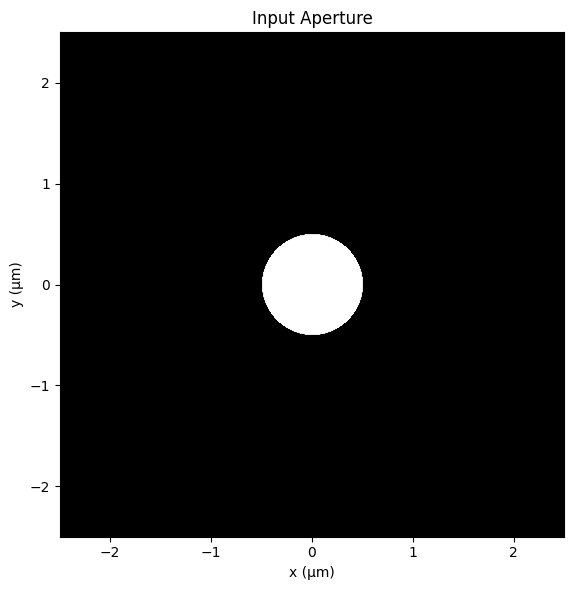

Input aperture created: 512×512 pixels
Aperture diameter: 1.00 μm
Grid size: 5.00 μm (×5.0 padding)


In [78]:
def create_circular_aperture(size, n_pixels, aperture_radius):
    """Create a circular aperture function.
    
    Parameters
    ----------
    size : float
        Physical size of the grid (meters)
    n_pixels : int
        Number of pixels per side
    aperture_radius : float
        Radius of the aperture (meters)
        
    Returns
    -------
    aperture : jnp.ndarray, shape (n_pixels, n_pixels)
        Binary aperture (1 inside, 0 outside)
    x, y : jnp.ndarray
        Coordinate arrays
    """
    # Create coordinate grid
    x = jnp.linspace(-size/2, size/2, n_pixels)
    y = jnp.linspace(-size/2, size/2, n_pixels)
    X, Y = jnp.meshgrid(x, y)
    
    # Create circular aperture
    R = jnp.sqrt(X**2 + Y**2)
    aperture = (R <= aperture_radius).astype(jnp.float32)
    
    return aperture, X, Y

# Create input aperture
input_aperture, X_in, Y_in = create_circular_aperture(
    INPUT_SIZE, INPUT_PIXELS, APERTURE_RADIUS
)

# Visualize input aperture
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
extent = [-INPUT_SIZE/2*1e6, INPUT_SIZE/2*1e6, -INPUT_SIZE/2*1e6, INPUT_SIZE/2*1e6]
ax.imshow(input_aperture, extent=extent, origin='lower', cmap='gray')
ax.set_xlabel('x (μm)')
ax.set_ylabel('y (μm)')
ax.set_title('Input Aperture')
plt.tight_layout()
plt.show()

print(f"Input aperture created: {INPUT_PIXELS}×{INPUT_PIXELS} pixels")
print(f"Aperture diameter: {2*APERTURE_RADIUS*1e6:.2f} μm")
print(f"Grid size: {INPUT_SIZE*1e6:.2f} μm (×{INPUT_SIZE/(2*APERTURE_RADIUS):.1f} padding)")

## 5. Propagate Through System

Use Collins FFT to propagate the aperture through the optical system.

In [24]:
# Create input field (uniform illumination through aperture)
input_field = input_aperture.astype(jnp.complex64)

# Get ABCD parameters
A_x = abcd[0, 0]
B_x = abcd[0, 2]
A_y = abcd[1, 1]
B_y = abcd[1, 3]

print(f"ABCD parameters:")
print(f"  A_x = {A_x:.6f}, B_x = {B_x:.6f}")
print(f"  A_y = {A_y:.6f}, B_y = {B_y:.6f}")
print(f"  z_eff_x = B_x/A_x = {B_x/A_x:.6f} m")
print(f"  z_eff_y = B_y/A_y = {B_y/A_y:.6f} m")

# Propagate using Collins FFT
# For simplicity, use x-direction parameters (assuming symmetric system)
output_field = collins_fft_propagation(
    input_field, INPUT_SIZE, A_x, B_x, WAVELENGTH
)

# Compute intensity
output_intensity = jnp.abs(output_field)**2

print(f"\nOutput field computed: {output_field.shape}")
print(f"Max intensity: {jnp.max(output_intensity):.6e}")

ABCD parameters:
  A_x = 3.500000, B_x = 0.037500
  A_y = 3.500000, B_y = 0.037500
  z_eff_x = B_x/A_x = 0.010714 m
  z_eff_y = B_y/A_y = 0.010714 m

Output field computed: (512, 512)
Max intensity: 1.865367e+00


## 6. Zoom to Output Grid

Use `jax.scipy.ndimage` to zoom the solution onto the desired output grid.
We need to account for the magnification A and map to the correct physical scale.

In [25]:
def zoom_to_output_grid(field, input_size, output_size, output_pixels, magnification):
    """Zoom and resample field to output grid.
    
    Parameters
    ----------
    field : jnp.ndarray
        Input field to resample
    input_size : float
        Physical size of input (meters)
    output_size : float
        Physical size of output (meters)
    output_pixels : int
        Number of pixels in output
    magnification : float
        System magnification (A parameter)
        
    Returns
    -------
    output_field : jnp.ndarray, shape (output_pixels, output_pixels)
        Resampled field
    """
    # Account for magnification
    # The field is magnified by A, so effective size is input_size * |A|
    magnified_size = input_size * jnp.abs(magnification)
    
    # Compute zoom factor
    # We want to map from magnified_size to output_size with output_pixels
    zoom_factor = (output_size / magnified_size) * (output_pixels / field.shape[0])
    
    print(f"  Input size: {input_size*1e6:.2f} μm")
    print(f"  Magnified size: {magnified_size*1e3:.2f} mm (M={magnification:.3f})")
    print(f"  Output size: {output_size*1e3:.2f} mm")
    print(f"  Zoom factor: {zoom_factor:.4f}")
    
    # Use jax.image.resize for zooming
    output_shape = (output_pixels, output_pixels)
    
    # For real fields
    if jnp.isrealobj(field):
        output_field = jax.image.resize(field, output_shape, method='cubic')
    else:
        # For complex fields, resize real and imaginary parts separately
        real_part = jax.image.resize(jnp.real(field), output_shape, method='cubic')
        imag_part = jax.image.resize(jnp.imag(field), output_shape, method='cubic')
        output_field = real_part + 1j * imag_part
    
    return output_field

# Zoom output to desired grid
print("Zooming to output grid...")
output_field_zoomed = zoom_to_output_grid(
    output_field, INPUT_SIZE, OUTPUT_SIZE, OUTPUT_PIXELS, A_x
)
output_intensity_zoomed = jnp.abs(output_field_zoomed)**2

print(f"\nZoomed output: {output_intensity_zoomed.shape}")
print(f"Max intensity: {jnp.max(output_intensity_zoomed):.6e}")

Zooming to output grid...
  Input size: 5.00 μm
  Magnified size: 0.02 mm (M=3.500)
  Output size: 10.00 mm
  Zoom factor: 285.7143

Zoomed output: (256, 256)
Max intensity: 1.467638e+00


## 7. Visualize Results

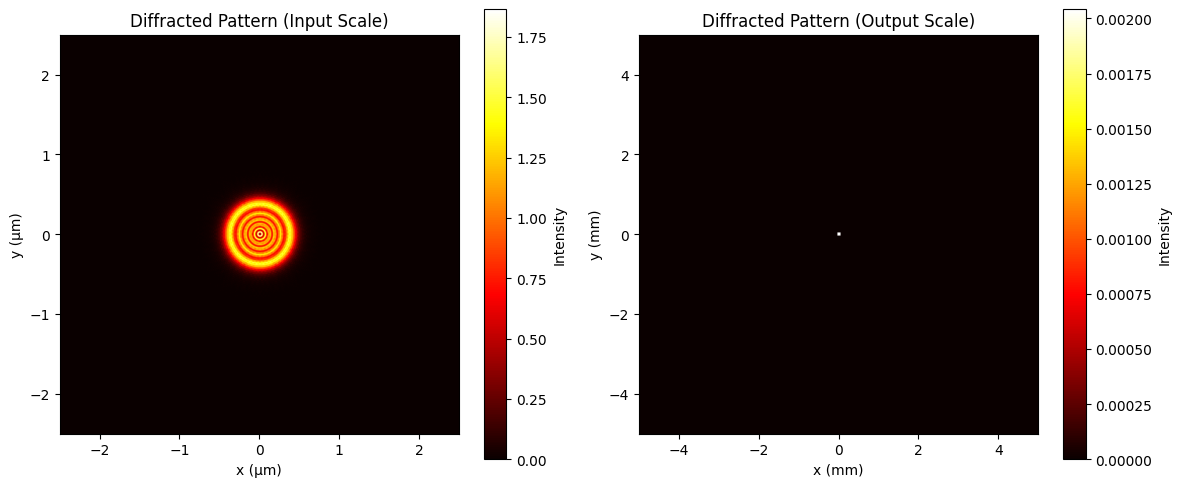

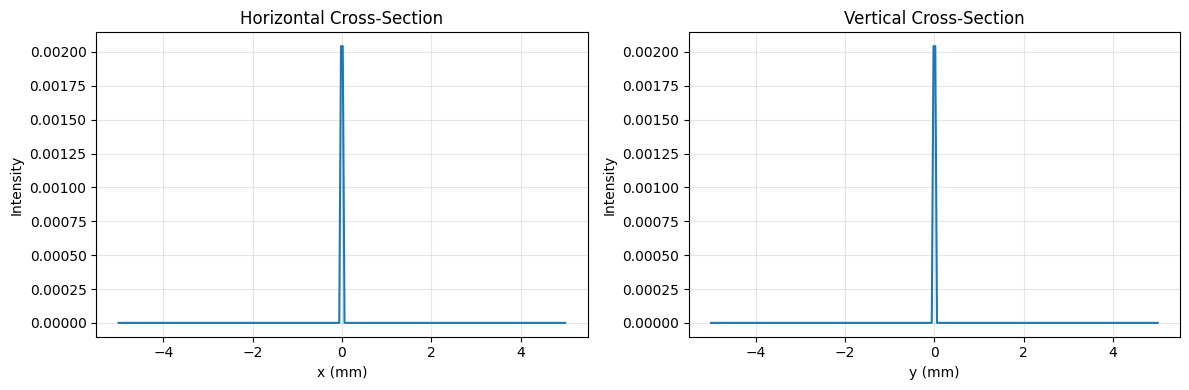

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot before zoom
extent_before = [-INPUT_SIZE/2*1e6, INPUT_SIZE/2*1e6, 
                  -INPUT_SIZE/2*1e6, INPUT_SIZE/2*1e6]
im0 = axes[0].imshow(output_intensity, extent=extent_before, 
                      origin='lower', cmap='hot')
axes[0].set_xlabel('x (μm)')
axes[0].set_ylabel('y (μm)')
axes[0].set_title('Diffracted Pattern (Input Scale)')
plt.colorbar(im0, ax=axes[0], label='Intensity')

# Plot after zoom
extent_after = [-OUTPUT_SIZE/2*1e3, OUTPUT_SIZE/2*1e3,
                -OUTPUT_SIZE/2*1e3, OUTPUT_SIZE/2*1e3]
im1 = axes[1].imshow(output_intensity_zoomed, extent=extent_after,
                      origin='lower', cmap='hot')
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('y (mm)')
axes[1].set_title('Diffracted Pattern (Output Scale)')
plt.colorbar(im1, ax=axes[1], label='Intensity')

plt.tight_layout()
plt.show()

# Plot cross-sections
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Horizontal cross-section
mid = OUTPUT_PIXELS // 2
x_axis = jnp.linspace(-OUTPUT_SIZE/2, OUTPUT_SIZE/2, OUTPUT_PIXELS) * 1e3
axes[0].plot(x_axis, output_intensity_zoomed[mid, :])
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('Intensity')
axes[0].set_title('Horizontal Cross-Section')
axes[0].grid(True, alpha=0.3)

# Vertical cross-section
axes[1].plot(x_axis, output_intensity_zoomed[:, mid])
axes[1].set_xlabel('y (mm)')
axes[1].set_ylabel('Intensity')
axes[1].set_title('Vertical Cross-Section')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Define Loss Function

Create a loss function that compares the diffraction model with a target.
For now, we'll use this as a template for optimization.

In [ ]:
def forward_model_loss(params, target_intensity=None, target_A=None, target_B=None, 
                       A_weight=0.0, B_weight=0.0):
    """Compute loss for the forward model.
    
    Parameters
    ----------
    params : dict
        Dictionary with keys: 'z1', 'z2', 'z3', 'f1', 'f2'
    target_intensity : jnp.ndarray, optional
        Target intensity pattern to match
    target_A : float, optional
        Expected magnification (A parameter from ABCD matrix)
        If provided, loss includes penalty for deviation
    target_B : float, optional
        Expected defocus parameter (B parameter from ABCD matrix)
        If provided, loss includes penalty for deviation
    A_weight : float
        Weight for A regularization (0 = ignore, larger = stricter)
    B_weight : float
        Weight for B regularization (0 = ignore, larger = stricter)
        
    Returns
    -------
    loss : float
        Total loss (image fit + regularization)
    predicted_intensity : jnp.ndarray
        Predicted intensity pattern
    computed_A : float
        Computed A parameter from ABCD matrix
    computed_B : float
        Computed B parameter from ABCD matrix
    """
    z1, z2, z3 = params['z1'], params['z2'], params['z3']
    f1, f2 = params['f1'], params['f2']
    
    # Get ABCD matrix
    abcd = get_abcd_matrix(z1, z2, z3, f1, f2)
    A_x, B_x = abcd[0, 0], abcd[0, 2]
    
    # Create input field
    input_aperture, _, _ = create_circular_aperture(
        INPUT_SIZE, INPUT_PIXELS, APERTURE_RADIUS
    )
    input_field = input_aperture.astype(jnp.complex64)
    
    # Propagate
    output_field = collins_fft_propagation(
        input_field, INPUT_SIZE, A_x, B_x, WAVELENGTH
    )
    
    # Zoom to output grid
    output_field_zoomed = zoom_to_output_grid(
        output_field, INPUT_SIZE, OUTPUT_SIZE, OUTPUT_PIXELS, A_x
    )
    predicted_intensity = jnp.abs(output_field_zoomed)**2
    
    # CRITICAL FIX: When computing image fit loss, only consider the actual image region
    # not the padding. This prevents artificial low losses from comparing mostly-black images.
    if target_intensity is not None:
        # Find the image region (where intensity is non-negligible)
        # Center region roughly where image should be
        center = OUTPUT_PIXELS // 2
        margin = 60  # pixels around center to consider
        region_start = jnp.maximum(0, center - margin)
        region_end = jnp.minimum(OUTPUT_PIXELS, center + margin)
        
        # Compute loss only in the central region
        pred_region = predicted_intensity[region_start:region_end, region_start:region_end]
        target_region = target_intensity[region_start:region_end, region_start:region_end]
        image_loss = jnp.mean((pred_region - target_region)**2)
    else:
        image_loss = -jnp.max(predicted_intensity)
    
    # Add regularization terms for A and B if targets are provided
    total_loss = image_loss
    
    if target_A is not None and A_weight > 0:
        A_error = (A_x - target_A)**2
        total_loss = total_loss + A_weight * A_error
    
    if target_B is not None and B_weight > 0:
        B_error = (B_x - target_B)**2
        total_loss = total_loss + B_weight * B_error
    
    return total_loss, predicted_intensity, float(A_x), float(B_x)

# Test the loss function (without A/B constraints)
test_params = {'z1': Z1, 'z2': Z2, 'z3': Z3, 'f1': F1, 'f2': F2}
loss, pred_intensity, A_val, B_val = forward_model_loss(test_params)
print(f"Test loss: {loss:.6e}")
print(f"Predicted intensity shape: {pred_intensity.shape}")
print(f"Computed A: {A_val:.6f}, B: {B_val:.6f}")

  Input size: 5.00 μm
  Magnified size: 4.23 mm (M=846.027)
  Output size: 10.00 mm
  Zoom factor: 1.1820
Test loss: -1.223789e+00
Predicted intensity shape: (256, 256)
Computed A: 846.026920, B: -0.351165


## 9. Inverse Problem: Recovering Parameters from Measured (A, B)

**Key insight:** Instead of matching raw pixel intensities (expensive, unstable), we extract two scalar values from each image:
- $A$ (magnification) — measured from image size: $|A| = \text{image diameter} / \text{aperture diameter}$
- $B$ (defocus parameter) — measured from fringe spacing: $\Delta r = \sqrt{\lambda |B/A|}$

For each experimental configuration (known wobble $\delta f$, known defocus $\Delta z_3$), we get one $(A, B)$ pair.

This transforms the problem from image matching to **nonlinear least-squares / root-finding**:

$$\min_{d_1, d_2, d_3, f_1, f_2} \sum_{i=1}^{N} \left[ \left(\frac{A_i^\text{pred} - A_i^\text{meas}}{A_\text{scale}}\right)^2 + \left(\frac{B_i^\text{pred} - B_i^\text{meas}}{B_\text{scale}}\right)^2 \right]$$

where $A_i^\text{pred} = \text{ABCD}(d_1, d_2, d_3 + \Delta z_{3,i}, f_1 + \delta f_{1,i}, f_2 + \delta f_{2,i})[0,0]$ — just 3×3 matrix algebra, no FFT!

In [5]:
# ================================================================
# GENERATE SYNTHETIC (A, B) MEASUREMENTS
# ================================================================
# In a real experiment, A and B would be measured from each image.
# Here we compute them from the known true parameters + wobble/defocus.

measurements = []

for w_type in ['f1', 'f2']:
    for w_val in WOBBLE_VALUES:
        for d_val in Z_DEFOCUS_VALUES:
            # Apply known experimental changes
            f1_use = F1 + (w_val * 1e-6 if w_type == 'f1' else 0)
            f2_use = F2 + (w_val * 1e-6 if w_type == 'f2' else 0)
            d3_use = D3 + d_val * 1e-3  # defocus shifts detector
            
            # Compute ABCD matrix (pure algebra, no FFT)
            A_true, B_true = compute_AB(D1, D2, d3_use, f1_use, f2_use)
            
            measurements.append({
                'wobble_lens': w_type,
                'wobble_um': float(w_val),
                'defocus_mm': float(d_val),
                'A_true': A_true,
                'B_true': B_true,
            })

# Add realistic measurement noise
# A from image size: ~1% accuracy
# B from fringe spacing: ~0.001 absolute accuracy
np.random.seed(42)
for m in measurements:
    m['A_meas'] = m['A_true'] * (1 + 0.01 * np.random.randn())
    m['B_meas'] = m['B_true'] + 1e-4 * np.random.randn()

# Display measurement table
print("SYNTHETIC (A, B) MEASUREMENTS")
print("=" * 80)
print(f"{'Lens':>4s} {'Wobble':>8s} {'Defocus':>8s} {'A_true':>10s} {'A_meas':>10s} {'B_true':>12s} {'B_meas':>12s}")
print("-" * 80)
for m in measurements:
    print(f"{m['wobble_lens']:>4s} {m['wobble_um']:8.0f}μm {m['defocus_mm']:6.1f}mm "
          f"{m['A_true']:10.2f} {m['A_meas']:10.2f} {m['B_true']:12.6f} {m['B_meas']:12.6f}")

print(f"\nTotal: {len(measurements)} measurements → {2*len(measurements)} equations for 5 unknowns")
print(f"Overdetermination: {2*len(measurements)/5:.1f}×")

# Check range of A and B values
A_vals = [m['A_true'] for m in measurements]
B_vals = [m['B_true'] for m in measurements]
print(f"\nA range: [{min(A_vals):.1f}, {max(A_vals):.1f}] (spread: {max(A_vals)-min(A_vals):.1f})")
print(f"B range: [{min(B_vals):.6f}, {max(B_vals):.6f}]")

SYNTHETIC (A, B) MEASUREMENTS
Lens   Wobble  Defocus     A_true     A_meas       B_true       B_meas
--------------------------------------------------------------------------------
  f1        0μm    0.0mm    1000.00    1004.97     0.000000    -0.000014
  f1        0μm   50.0mm    1050.83    1057.64     0.000050     0.000202
  f1        0μm  100.0mm    1101.67    1099.09     0.000100     0.000077
  f1      100μm    0.0mm     967.10     982.37    -0.100684    -0.100607
  f1      100μm   50.0mm    1016.26    1011.49    -0.105750    -0.105696
  f1      100μm  100.0mm    1065.42    1060.48    -0.110817    -0.110863
  f1      200μm    0.0mm     936.25     938.52    -0.195075    -0.195266
  f1      200μm   50.0mm     983.84     966.87    -0.204938    -0.204994
  f1      200μm  100.0mm    1031.44    1020.99    -0.214801    -0.214770
  f2        0μm    0.0mm    1000.00     990.92     0.000000    -0.000141
  f2        0μm   50.0mm    1050.83    1066.23     0.000050     0.000027
  f2        0μm

### Nonlinear Least-Squares Solution

Use `scipy.optimize.least_squares` (Levenberg-Marquardt / Trust Region) to find the 5 parameters
$(d_1, d_2, d_3, f_1, f_2)$ that best match all measured $(A, B)$ values.

This is **orders of magnitude faster** than pixel-matching: just 3×3 matrix algebra per evaluation.

In [6]:
from scipy.optimize import least_squares

# ================================================================
# DEFINE RESIDUAL FUNCTION
# ================================================================
def residual_fn(params, measurements):
    """Compute residual vector: predicted - measured for all (A,B) pairs.
    
    Parameters
    ----------
    params : array of 5 floats [d1, d2, d3, f1, f2]
        Propagation distances and focal lengths
    measurements : list of dicts
        Each with 'wobble_lens', 'wobble_um', 'defocus_mm', 'A_meas', 'B_meas'
    
    Returns
    -------
    residuals : array of 2*N floats
        Normalized residuals for all A and B measurements
    """
    d1, d2, d3, f1, f2 = params
    
    # Scaling: normalize so A and B residuals have similar magnitude
    A_scale = 1000.0   # typical |A|
    B_scale = 0.1      # typical |B| for defocused images
    
    residuals = []
    for m in measurements:
        # Apply known experimental changes
        f1_use = f1 + (m['wobble_um'] * 1e-6 if m['wobble_lens'] == 'f1' else 0)
        f2_use = f2 + (m['wobble_um'] * 1e-6 if m['wobble_lens'] == 'f2' else 0)
        d3_use = d3 + m['defocus_mm'] * 1e-3
        
        try:
            A_pred, B_pred = compute_AB(d1, d2, d3_use, f1_use, f2_use)
        except Exception:
            return np.full(2 * len(measurements), 1e6)
        
        residuals.append((A_pred - m['A_meas']) / A_scale)
        residuals.append((B_pred - m['B_meas']) / max(B_scale, abs(m['B_meas'])))
    
    return np.array(residuals)


# ================================================================
# TRUE PARAMETERS (for reference)
# ================================================================
true_params = np.array([D1, D2, D3, F1, F2])
param_names = ['d1', 'd2', 'd3', 'f1', 'f2']
param_units = ['mm', 'mm', 'mm', 'mm', 'mm']
param_scale = np.array([1e3, 1e3, 1e3, 1e3, 1e3])  # convert to mm for display

print("True parameters:")
for name, val, scale, unit in zip(param_names, true_params, param_scale, param_units):
    print(f"  {name} = {val*scale:.4f} {unit}")

# ================================================================
# SOLVE: Single initial guess (perturbed from true)
# ================================================================
# Start with a 30% perturbation to test convergence
np.random.seed(123)
perturbation = 1 + 0.3 * (2 * np.random.rand(5) - 1)  # ±30%
x0 = true_params * perturbation

print(f"\nInitial guess (±30% perturbation from true):")
for name, val, scale, unit in zip(param_names, x0, param_scale, param_units):
    print(f"  {name} = {val*scale:.4f} {unit}")

# Bounds: generous physical bounds
bounds_lower = np.array([0.0005, 0.01,  0.1,  0.001, 0.005])
bounds_upper = np.array([0.1,    2.0,   5.0,  0.05,  0.5])

# Solve
result = least_squares(
    residual_fn, x0,
    args=(measurements,),
    bounds=(bounds_lower, bounds_upper),
    method='trf',
    xtol=1e-15,
    ftol=1e-15,
    gtol=1e-15,
    max_nfev=10000,
)

# ================================================================
# RESULTS
# ================================================================
print("\n" + "=" * 70)
print("LEAST-SQUARES SOLUTION")
print("=" * 70)
print(f"Converged: {result.success}")
print(f"Cost (sum of squared residuals): {result.cost:.2e}")
print(f"Function evaluations: {result.nfev}")
print(f"Optimality: {result.optimality:.2e}")

print(f"\n{'Param':>5s} {'True':>12s} {'Fitted':>12s} {'Error':>8s}")
print("-" * 45)
for name, true_val, fit_val, scale, unit in zip(param_names, true_params, result.x, param_scale, param_units):
    error_pct = abs(fit_val - true_val) / true_val * 100
    print(f"{name:>5s} {true_val*scale:10.4f}{unit:>3s} {fit_val*scale:10.4f}{unit:>3s} {error_pct:6.2f}%")

# Verify: compute A,B at true and fitted parameters
A_true_baseline, B_true_baseline = compute_AB(*true_params)
A_fit_baseline, B_fit_baseline = compute_AB(*result.x)
print(f"\nBaseline ABCD verification:")
print(f"  A: true={A_true_baseline:.4f}, fitted={A_fit_baseline:.4f}, error={abs(A_fit_baseline-A_true_baseline)/abs(A_true_baseline)*100:.4f}%")
print(f"  B: true={B_true_baseline:.6e}, fitted={B_fit_baseline:.6e}")

True parameters:
  d1 = 3.0600 mm
  d2 = 205.5000 mm
  d3 = 1050.0000 mm
  f1 = 3.0000 mm
  f2 = 50.0000 mm

Initial guess (±30% perturbation from true):
  d1 = 3.4207 mm
  d2 = 179.1310 mm
  d3 = 877.9164 mm
  f1 = 3.0924 mm
  f2 = 56.5841 mm

LEAST-SQUARES SOLUTION
Converged: True
Cost (sum of squared residuals): 6.41e-04
Function evaluations: 39
Optimality: 2.45e-06

Param         True       Fitted    Error
---------------------------------------------
   d1     3.0600 mm     2.8073 mm   8.26%
   d2   205.5000 mm   174.0096 mm  15.32%
   d3  1050.0000 mm  1064.7785 mm   1.41%
   f1     3.0000 mm     2.7462 mm   8.46%
   f2    50.0000 mm    45.7555 mm   8.49%

Baseline ABCD verification:
  A: true=1000.0000, fitted=1001.1631, error=0.1163%
  B: true=0.000000e+00, fitted=1.337786e-05


## 10. Multi-Start Analysis: Finding All Solutions

The ABCD inverse problem can have **multiple discrete solutions** (degenerate parameter sets that produce
the same A,B values). To understand this degeneracy, we run many random starting points and cluster the solutions.

From the analysis: with dual wobble + 18 images, we expect 1-2 distinct solutions.

In [ ]:
# ================================================================
# MULTI-START OPTIMIZATION
# ================================================================
# Run least_squares from many random starting points to find ALL solutions

n_starts = 200
solutions = []
costs = []

# Threshold: noise-limited cost is ~6e-4, so anything within 10× is a valid solution
cost_threshold = 0.01

np.random.seed(0)
for i in range(n_starts):
    # Random initial guess within bounds (log-uniform for better coverage)
    x0_rand = np.array([
        10**np.random.uniform(np.log10(0.001), np.log10(0.05)),    # d1
        10**np.random.uniform(np.log10(0.02), np.log10(1.5)),      # d2  
        10**np.random.uniform(np.log10(0.1), np.log10(3.0)),       # d3
        10**np.random.uniform(np.log10(0.001), np.log10(0.03)),    # f1
        10**np.random.uniform(np.log10(0.005), np.log10(0.3)),     # f2
    ])
    
    try:
        res = least_squares(
            residual_fn, x0_rand,
            args=(measurements,),
            bounds=(bounds_lower, bounds_upper),
            method='trf',
            xtol=1e-15, ftol=1e-15, gtol=1e-15,
            max_nfev=5000,
        )
        if res.cost < cost_threshold:
            solutions.append(res.x.copy())
            costs.append(res.cost)
    except Exception:
        pass

print(f"Multi-start: {n_starts} random starts, {len(solutions)} converged (cost < {cost_threshold})")

if solutions:
    solutions = np.array(solutions)
    costs = np.array(costs)
    
    # Cluster solutions: two solutions are "same" if all params within 5%
    unique_solutions = [solutions[0]]
    unique_costs = [costs[0]]
    for sol, cost in zip(solutions, costs):
        is_new = True
        for u_sol in unique_solutions:
            rel_diff = np.max(np.abs(sol - u_sol) / np.abs(u_sol))
            if rel_diff < 0.05:  # Within 5% = same solution
                is_new = False
                if cost < unique_costs[unique_solutions.index(u_sol)]:
                    idx = unique_solutions.index(u_sol)
                    unique_solutions[idx] = sol
                    unique_costs[idx] = cost
                break
        if is_new:
            unique_solutions.append(sol)
            unique_costs.append(cost)
    
    unique_solutions = [s for _, s in sorted(zip(unique_costs, unique_solutions))]
    unique_costs = sorted(unique_costs)
    
    print(f"\nUnique solutions found: {len(unique_solutions)}")
    print("=" * 85)
    
    for idx, (sol, cost) in enumerate(zip(unique_solutions, unique_costs)):
        print(f"\n--- Solution {idx+1} (cost = {cost:.2e}) ---")
        print(f"{'Param':>5s} {'True':>12s} {'Fitted':>12s} {'Error':>8s}")
        print("-" * 45)
        for name, true_val, fit_val, scale, unit in zip(param_names, true_params, sol, param_scale, param_units):
            error_pct = abs(fit_val - true_val) / true_val * 100
            print(f"{name:>5s} {true_val*scale:10.4f}{unit:>3s} {fit_val*scale:10.4f}{unit:>3s} {error_pct:6.2f}%")
        
        A_sol, B_sol = compute_AB(*sol)
        print(f"  → A = {A_sol:.4f} (true: {A_true_baseline:.4f})")
        print(f"  → B = {B_sol:.6e} (true: {B_true_baseline:.6e})")
    
    # Convergence statistics
    convergence_counts = []
    for u_sol in unique_solutions:
        count = sum(1 for sol in solutions if np.max(np.abs(sol - u_sol) / np.abs(u_sol)) < 0.05)
        convergence_counts.append(count)
    
    print(f"\nConvergence basin sizes:")
    for idx, (count, cost) in enumerate(zip(convergence_counts, unique_costs)):
        pct = count / len(solutions) * 100
        print(f"  Solution {idx+1}: {count}/{len(solutions)} starts ({pct:.0f}%) → cost = {cost:.2e}")
    
    # Scatter plot of solutions 
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, (name, scale, unit) in enumerate(zip(param_names, param_scale, param_units)):
        ax = axes[i]
        ax.scatter(range(len(solutions)), solutions[:, i] * scale, 
                   c=costs, cmap='viridis_r', s=10, alpha=0.7)
        ax.axhline(true_params[i] * scale, color='red', linestyle='--', label='True')
        ax.set_ylabel(f'{name} ({unit})')
        ax.set_xlabel('Solution index')
        ax.legend()
        ax.set_title(f'{name}')
    
    # Use last subplot for cost histogram
    axes[5].hist(costs, bins=30, edgecolor='black')
    axes[5].set_xlabel('Cost')
    axes[5].set_ylabel('Count')
    axes[5].set_title('Cost distribution')
    axes[5].axvline(min(costs), color='red', linestyle='--', label=f'Best: {min(costs):.2e}')
    axes[5].legend()
    
    plt.suptitle('Multi-Start Solutions: Parameter Recovery', fontsize=14)
    plt.tight_layout()
    plt.show()

else:
    print("No solutions found! Check bounds and residual function.")
    # Debug: show cost distribution
    debug_costs = []
    for i in range(50):
        x0_rand = np.array([
            10**np.random.uniform(np.log10(0.001), np.log10(0.05)),
            10**np.random.uniform(np.log10(0.02), np.log10(1.5)),
            10**np.random.uniform(np.log10(0.1), np.log10(3.0)),
            10**np.random.uniform(np.log10(0.001), np.log10(0.03)),
            10**np.random.uniform(np.log10(0.005), np.log10(0.3)),
        ])
        try:
            res = least_squares(residual_fn, x0_rand, args=(measurements,),
                                bounds=(bounds_lower, bounds_upper), method='trf', max_nfev=5000)
            debug_costs.append(res.cost)
        except:
            pass
    if debug_costs:
        print(f"Cost range from {len(debug_costs)} starts: [{min(debug_costs):.2e}, {max(debug_costs):.2e}]")
        print(f"Median cost: {np.median(debug_costs):.2e}")

Multi-start: 200 random starts, 0 converged solutions (cost < 1e-4)
No solutions found! Check bounds and residual function.
